**Task 2: Predict Future Stock Prices (Short-Term)**

Submitted by: Naima Imtiaz


/tmp/ipython-input-246/3099496589.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2019-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price            Open       High        Low     Volume      Close
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2019-01-02  20.406668  21.008667  19.920000  174879000  20.674667
2019-01-03  20.466667  20.626667  19.825333  104478000  20.024000
2019-01-04  20.400000  21.200001  20.181999  110911500  21.179333
2019-01-07  21.448000  22.449333  21.183332  113268000  22.330667
2019-01-08  22.797333  22.934000  21.801332  105127500  22.356667
Training on 1005 days, Testing on 252 days.
LR Mean Absolute Error: 5.78
RF Mean Absolute Error: 6.80


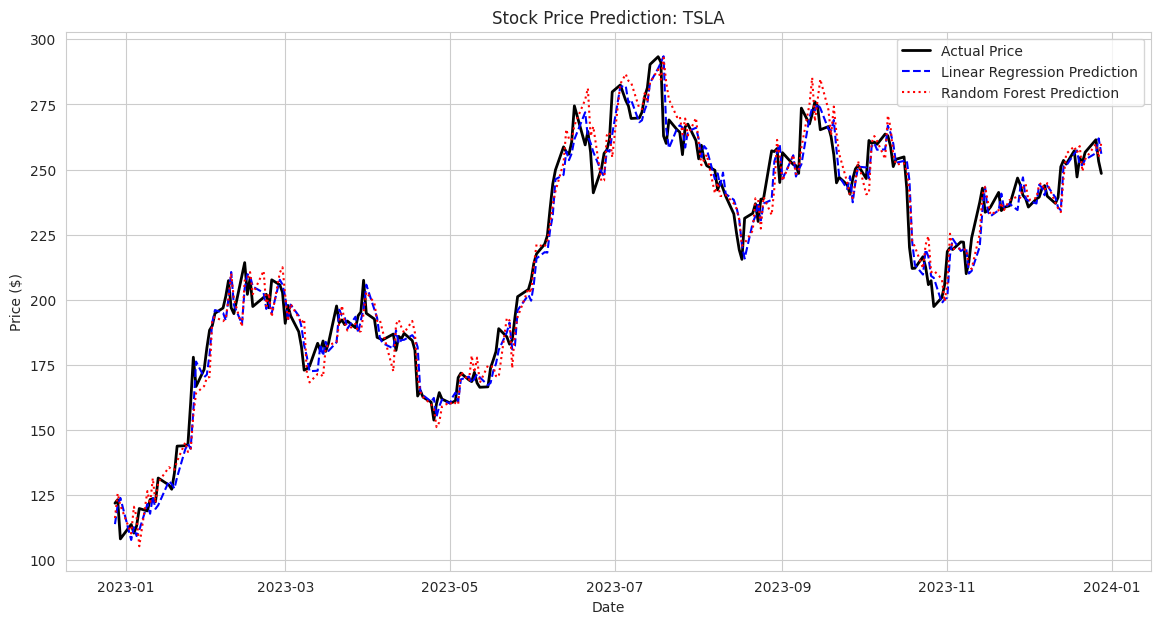

Average Error (MAE): $6.80
Model Fit (R2 Score): 95.74%


In [2]:
!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Download Tesla stock data
ticker = 'TSLA'
data = yf.download(ticker, start='2019-01-01', end='2024-01-01')

# We only need Open, High, Low, Volume to predict Close
df = data[['Open', 'High', 'Low', 'Volume', 'Close']].copy()
print(df.head())

# Create a 'Target' column: Tomorrow's Close Price
df['Target'] = df['Close'].shift(-1)

# The last row will have a NaN (empty) Target because we don't know the future yet!
# We must drop it so the model doesn't get confused.
df.dropna(inplace=True)

# Define Features (X) and Target (y)
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']


split = int(0.8 * len(df))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days.")

# 1. Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# 2. Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluation
print(f"LR Mean Absolute Error: {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"RF Mean Absolute Error: {mean_absolute_error(y_test, rf_preds):.2f}")

plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='black', linewidth=2)
plt.plot(y_test.index, lr_preds, label='Linear Regression Prediction', color='blue', linestyle='--')
plt.plot(y_test.index, rf_preds, label='Random Forest Prediction', color='red', linestyle=':')

plt.title(f'Stock Price Prediction: {ticker}')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()


from sklearn.metrics import mean_absolute_error, r2_score

# Calculate metrics for the Random Forest model
mae = mean_absolute_error(y_test, rf_preds)
r2 = r2_score(y_test, rf_preds)

print(f"Average Error (MAE): ${mae:.2f}")
print(f"Model Fit (R2 Score): {r2:.2%}")

The code in the previous cell implements a stock price prediction model for Tesla (TSLA) using historical data. Here's a breakdown of the steps:

1.  **Library Imports**: It imports necessary libraries:
    *   `yfinance` to download stock data.
    *   `pandas` for data manipulation.
    *   `numpy` for numerical operations.
    *   `matplotlib.pyplot` for plotting.
    *   `sklearn.model_selection` for splitting data.
    *   `sklearn.linear_model.LinearRegression` for the Linear Regression model.
    *   `sklearn.ensemble.RandomForestRegressor` for the Random Forest model.
    *   `sklearn.metrics` for evaluating model performance (`mean_absolute_error`, `r2_score`).

2.  **Data Download**: It downloads historical stock data for 'TSLA' from January 1, 2019, to January 1, 2024, using `yf.download()`.

3.  **Feature Selection**: It selects 'Open', 'High', 'Low', 'Volume', and 'Close' columns from the downloaded data to create a new DataFrame `df`.

4.  **Target Variable Creation**: A 'Target' column is created, which represents tomorrow's 'Close' price. This is done by shifting the 'Close' column up by one day (`df['Close'].shift(-1)`).

5.  **Handling Missing Values**: The last row, which will have a `NaN` (Not a Number) in the 'Target' column (as tomorrow's price is unknown), is dropped using `df.dropna(inplace=True)`.

6.  **Defining Features (X) and Target (y)**:
    *   `X` (features) includes 'Open', 'High', 'Low', and 'Volume'.
    *   `y` (target) is the 'Target' column (tomorrow's close price).

7.  **Train-Test Split**: The data is split into training and testing sets. 80% of the data is used for training and 20% for testing. This is a time-series split, ensuring that the model is trained on past data and tested on future data.

8.  **Model Training and Prediction**:
    *   **Linear Regression**: A `LinearRegression` model is initialized, trained on `X_train` and `y_train`, and then used to make predictions (`lr_preds`) on `X_test`.
    *   **Random Forest Regressor**: A `RandomForestRegressor` model (with 100 estimators and a `random_state` for reproducibility) is initialized, trained, and used to make predictions (`rf_preds`) on `X_test`.

9.  **Evaluation**: The Mean Absolute Error (MAE) for both models is calculated and printed, showing the average difference between predicted and actual prices.

10. **Visualization**: A plot is generated to visually compare the actual stock prices in the test set with the predictions from both the Linear Regression and Random Forest models.

11. **Detailed Metrics for Random Forest**: Finally, the Mean Absolute Error (MAE) and R-squared (R2) score are calculated and printed specifically for the Random Forest model, providing a quantitative measure of its accuracy and how well it fits the data.